In [24]:
#Anti crash text
import torch
import os

# 1. THE UNIVERSAL SWITCH: Keep this for Kaggle/Colab later
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Project running on: {device}")

# 2. THE RAM SAVER: Prevents Windows from crashing if memory gets tight
# This tells the DataLoader not to create too many sub-processes
NUM_WORKERS = 0 

# 3. VERIFY SPACE:
print(f"PyTorch size in memory is now optimized for CPU.")

Project running on: cpu
PyTorch size in memory is now optimized for CPU.


In [25]:
import torch # base library for tensor operations
from torch import nn # neural network module, has blocks like macs
from torch import optim # optimization algorithms tune wieghts to reduce errors
from torchvision import datasets, transforms # for loading and transforming image data
from torch.utils.data import DataLoader, random_split # for batching and splitting datasets


In [26]:
model1 = nn.Sequential(
    nn.Linear(28 * 28, 64),   #size of image is 28x28, so we flatten it to 784
                          #and then pass it through a linear layer to get 64 features/neurons
    nn.ReLU(),    # relu is a non-linear activation/ threshold logic
    nn.Linear(64,64), # another linear layer that takes the 64 features from the previous layer and outputs 64 features
    nn.ReLU(),   # activation function to introduce non-linearity
    nn.Linear(64,10)  # final layer that maps the 64 features to 10 output classes (digits 0-9)             
)

#nn.linear(28*28,64) is a series of multiply and accumulate operations that transforms the input data (flattened image) into a new representation with 64 features.
# Each of the 64 output features is a weighted sum of the 784 input pixels, plus a bias term.
# The weights and biases are learned during training to help the model make accurate predictions.
# y = wx + b is the mathematical representation of this operation, where w represents the weights, x is the input data, and b is the bias.
#nn.relu - rectified linear unit is an activation function that introduces non-linearity into the model.
# It outputs the input directly if it is positive; otherwise, it outputs zero.
# This helps the model learn complex patterns in the data.


In [27]:
#loss function - how we measure failure of the model to predict correctly
loss_fn = nn.CrossEntropyLoss()
#this is a specialized loss functio formula for classification(picking 1 out of 10 digits)
#like a comparator compared the desired output with the actual output and outputs an error signal


In [28]:
#Optimizer- how we change the weights based on the error
optimizer = optim.SGD(model1.parameters(), lr=1e-2)

#Stochastic Gradient Descent is a simple optimization algorithm that updates the model's weights in the direction that reduces the loss.

#model1parameters gives all the weights and biases to change

#lr = learning rate says how much wieghts change

In [29]:
#Data pipeline
#shd save some data to ensure the model learned the patterns
train_data =datasets.MNIST('data',train=True, download = True, transform=transforms.ToTensor())
#datadets.mnist download 60k images to data folder
#transform part turn the raw images into matrices of numbers(tensors), cpu understands

train, val = random_split(train_data , [55000, 5000])
#train- uses these over and over to learn the patterns
#val- uses these to check if the model is learning the
# patterns or just memorizing the data

train_loader = DataLoader(train, batch_size = 32,
 shuffle=True, 
num_workers=0,      # Stops background processes from hanging
pin_memory=False)    # Saves RAM by not "pinning" data)
val_loader = DataLoader(val, batch_size =32)

#dataloader- buffer engine that loads data in batches and
# feeds it to the model during training
#batch size 32 saves ram
#by adding val_loader (validation accuracy)
#we can check if the model is learning the patterns or 
# just memorizing the data




In [30]:
#training the model
#number of times to go through the entire dataset
epochs = 5

train_losses = [] # The X-axis will be 'Epochs', the Y-axis will be 'Loss'
val_losses = []

#train lossess is the list that gives us how much error the model has at epoch
#val losses (validation loss) is the list that gives us how much error the
#model has which is valid that is without memorizing the data, means
#it can recognize the patterns and not just memorize the data


for epoch in range(epochs):
    #1 model in training mode
    model1.train()
    #enables all training features

    #track total loss for this epoch
    running_loss = 0.0
    
    #2 loop through data in small batches(32 images at a time)
    for batch_idx, (data ,targets) in enumerate(train_loader):
        #flatten the 28x28 image to 784 vector
        data = data.reshape(-1,28*28)
        #converting to single row of 784 values/pixels
        
        #step 1 forward pass(input -> logic -> output)
        scores = model1(data)
        
        #step 2 calculate loss(how farr off is our model)
        loss = loss_fn(scores, targets)
        
        #step 3 zero gradients(gradients/errors)
        optimizer.zero_grad()
        
        #step 4 perform backpropagation, update weights
        #backpropagation is the process of calculating the gradients of the 
        # loss with respect to each weight in the model, allowing us to understand
        # how to adjust the weights to minimize the loss
        loss.backward()
        
        running_loss += loss.item()
        
        #5 gradient descent(update weights)
        optimizer.step()
        
        if batch_idx %100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}")
        #batchidx says print status update every 100 batches
        #len(Trainloader) shows total distance of batches in an epoch 
        #loss item - raw numer out of the pyotrch tensor

    
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Then run a quick Validation Loop (Optional but recommended)
    model1.eval() # Set to "Read Only" mode
    val_loss = 0
    with torch.no_grad():
        for data, targets in val_loader:
            data = data.reshape(-1, 784)
            output = model1(data)
            val_loss += loss_fn(output, targets).item()
    
    val_losses.append(val_loss / len(val_loader))
    print(f"==> Epoch {epoch+1} Complete. Avg Train Loss: {avg_loss:.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

Epoch [1/5], Batch [0/1719], Loss: 2.3089
Epoch [1/5], Batch [100/1719], Loss: 2.2504
Epoch [1/5], Batch [200/1719], Loss: 2.2037
Epoch [1/5], Batch [300/1719], Loss: 2.2083
Epoch [1/5], Batch [400/1719], Loss: 2.0319
Epoch [1/5], Batch [500/1719], Loss: 1.7924
Epoch [1/5], Batch [600/1719], Loss: 1.5350
Epoch [1/5], Batch [700/1719], Loss: 1.1444
Epoch [1/5], Batch [800/1719], Loss: 0.8606
Epoch [1/5], Batch [900/1719], Loss: 0.6772
Epoch [1/5], Batch [1000/1719], Loss: 0.7385
Epoch [1/5], Batch [1100/1719], Loss: 0.5522
Epoch [1/5], Batch [1200/1719], Loss: 0.6507
Epoch [1/5], Batch [1300/1719], Loss: 0.6234
Epoch [1/5], Batch [1400/1719], Loss: 0.4500
Epoch [1/5], Batch [1500/1719], Loss: 0.9068
Epoch [1/5], Batch [1600/1719], Loss: 0.5300
Epoch [1/5], Batch [1700/1719], Loss: 0.3634
==> Epoch 1 Complete. Avg Train Loss: 1.2035, Val Loss: 0.4838
Epoch [2/5], Batch [0/1719], Loss: 0.6142
Epoch [2/5], Batch [100/1719], Loss: 0.4089
Epoch [2/5], Batch [200/1719], Loss: 0.2659
Epoch [2/

In [31]:
# Load the test dataset specifically
test_data = datasets.MNIST('data', train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_data, batch_size=len(test_data))

# This forces the test data into the variables your export script expects
data_iter = iter(test_loader)
x_test, y_test = next(data_iter)

# Convert from PyTorch tensors to numpy arrays for the export script
x_test = x_test.numpy().reshape(-1, 28, 28)
y_test = y_test.numpy()

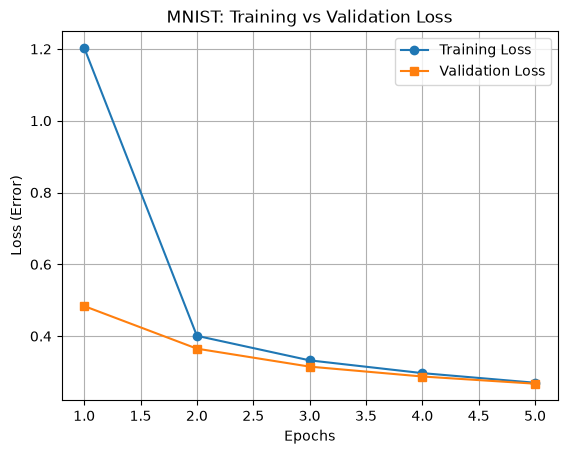

In [32]:
import matplotlib.pyplot as plt

# X-axis values (1 to 5)
epochs_range = range(1, len(train_losses) + 1)

plt.plot(epochs_range, train_losses, label='Training Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='s')

plt.xlabel('Epochs')
plt.ylabel('Loss (Error)')
plt.title('MNIST: Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [35]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random

# 1. Load MNIST Dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# 2. Define the Neural Network Model
class SimpleMNISTModel(nn.Module):
    def __init__(self):
        super(SimpleMNISTModel, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 10) # 784 pixels to 10 digits

    def forward(self, x):
        x = x.view(-1, 28 * 28) # Flatten image
        x = self.fc1(x)
        return x

model = SimpleMNISTModel()

# 3. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 4. Training Loop (1 Epoch)
model.train()
for epoch in range(1):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

print("Training Complete!\n")

# 5. Export Weights, Biases, and Pixels to match Verilog ROM Requirements
weights = model.fc1.weight.detach().cpu().numpy().flatten()
biases = model.fc1.bias.detach().cpu().numpy()

# Export weights_all.txt (Strictly 7,840 lines)
with open("weights_all.txt", "w") as f:
    for w in weights:
        val = int(w * 256) & 0xFFFF
        f.write(f"{val:04X}\n")

# Export bias_all.txt (Strictly 10 lines)
with open("bias_all.txt", "w") as f:
    for b in biases:
        val = int(b * 256) & 0xFFFFFFFF
        f.write(f"{val:08X}\n")

# Pick a RANDOM test image from the test set
random_index = random.randint(0, len(test_dataset) - 1)
sample_image, true_label = test_dataset[random_index]

# Export sample pixels.txt (Strictly 784 lines)
flat_pixels = sample_image.flatten().numpy()
with open("pixels.txt", "w") as f:
    for p in flat_pixels:
        val = int(p *256) & 0xFFFF
        f.write(f"{val:04X}\n")

print(f"Exported text files successfully! (Random Test Image True Label: {true_label})")

# 6. Run Softmax to get Probabilities for All Digits
model.eval()
with torch.no_grad():
    # Add batch dimension back: shape [1, 1, 28, 28]
    img_tensor = sample_image.unsqueeze(0)
    raw_scores = model(img_tensor)
    
    # Softmax converts raw scores into percentages/probabilities that add up to 100%
    probabilities = torch.softmax(raw_scores, dim=1).squeeze()

print("\n--- Model Prediction Probabilities for All Digits ---")
for digit in range(10):
    prob_percentage = probabilities[digit].item() * 100
    print(f"Digit {digit}: {prob_percentage:6.2f}%")

predicted_digit = torch.argmax(probabilities).item()
print(f"\nFinal Predicted Digit: {predicted_digit} (Actual True Label: {true_label})")

Training Complete!

Exported text files successfully! (Random Test Image True Label: 1)

--- Model Prediction Probabilities for All Digits ---
Digit 0:   0.01%
Digit 1:  95.27%
Digit 2:   0.46%
Digit 3:   0.59%
Digit 4:   0.12%
Digit 5:   1.04%
Digit 6:   0.51%
Digit 7:   0.74%
Digit 8:   0.98%
Digit 9:   0.28%

Final Predicted Digit: 1 (Actual True Label: 1)
